<a href="https://colab.research.google.com/github/Mandira124/ML_DL-Projects/blob/main/Unit3_AdvancedVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 3 Assignment – Advanced Vision Tasks

**Assignment Title:** Object Detection using YOLOv5 with Transfer Learning  
**Student Name:** Mandira Sharma

**Date:** May 2026  
**Dataset:** Pascal VOC 2012 (subset)

## 1. Objective

- Load a pre-trained YOLOv5 model and run it on real images
- Understand how transfer learning works in object detection
- Fine-tune the model on a small VOC subset
- Compare results before and after fine-tuning
- Get some basic metrics like loss and see if the model improves

## 2. Theoretical Background

I learned that **object detection** is not just classifying what's in an image, but also finding *where* the objects are using bounding boxes. So the model outputs both a label and coordinates.

**YOLO** stands for "You Only Look Once". I found this interesting because older methods used to scan the image multiple times (like sliding windows), but YOLO does everything in one forward pass. It divides the image into a grid and each cell predicts boxes and class probabilities directly. That's why it's fast.

**Transfer learning** means we don't train from scratch. The model already learned useful features (edges, textures, shapes) from a huge dataset like COCO. We just take those weights and fine-tune the last few layers on our smaller dataset. I noticed this really helps when we don't have a lot of data.

## 3. Dataset Description

I'm using a subset of the **Pascal VOC 2012** dataset.

- **Source:** http://host.robots.ox.ac.uk/pascal/VOC/voc2012/
- **Classes:** 20 object categories (person, car, dog, cat, bicycle, etc.)
- **Full dataset size:** ~11,500 annotated images
- **Subset I'm using:** ~500 images for training, ~100 for validation (to keep it manageable)
- **Split:** roughly 80% train / 20% val
- **Annotations:** bounding boxes + class labels in XML format (converted to YOLO .txt format)

I picked this because it's a well-known real dataset and the YOLOv5 repo has good instructions for using it.

## 4. Setup & Installation

In [1]:
# Install dependencies
import subprocess
import os

# Clone YOLOv5 if not already there
if not os.path.exists('yolov5'):
    subprocess.run(['git', 'clone', 'https://github.com/ultralytics/yolov5'], check=True)
    subprocess.run(['pip', 'install', '-r', 'yolov5/requirements.txt', '-q'], check=True)

print('Setup done.')

Setup done.


In [2]:
import torch
import yaml
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image

sys.path.insert(0, 'yolov5')

print('PyTorch version:', torch.__version__)
print('GPU available:', torch.cuda.is_available())

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using:', DEVICE)

PyTorch version: 2.10.0+cu128
GPU available: True
Using: cuda


## 5. Dataset Preparation

Pascal VOC uses XML annotations. YOLOv5 needs .txt files with normalized bounding boxes.  
I'll download a small VOC subset and convert the annotations.

In [3]:
import urllib.request
import tarfile

# Download VOC 2012 trainval (only if not already downloaded)
VOC_URL = 'http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar'
TAR_PATH = 'VOCtrainval_11-May-2012.tar'

if not os.path.exists('VOCdevkit'):
    print('Downloading VOC 2012 (this may take a while)...')
    urllib.request.urlretrieve(VOC_URL, TAR_PATH)
    with tarfile.open(TAR_PATH) as tar:
        tar.extractall('.')
    print('Extracted.')
else:
    print('VOC data already exists.')

/tmp/ipykernel_8209/2066565630.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')


Extracted.


In [4]:
import xml.etree.ElementTree as ET
import shutil
import random

# VOC class list
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def convert_voc_to_yolo(xml_path, img_w, img_h):
    """Convert VOC XML annotation to YOLO format lines."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    lines = []
    for obj in root.findall('object'):
        cls_name = obj.find('name').text
        if cls_name not in VOC_CLASSES:
            continue
        cls_id = VOC_CLASSES.index(cls_name)
        bbox = obj.find('bndbox')
        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)
        # normalize
        cx = (xmin + xmax) / 2.0 / img_w
        cy = (ymin + ymax) / 2.0 / img_h
        w  = (xmax - xmin) / img_w
        h  = (ymax - ymin) / img_h
        lines.append(f'{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')
    return lines


# Build a small subset: 500 train + 100 val
VOC_IMG_DIR  = 'VOCdevkit/VOC2012/JPEGImages'
VOC_ANN_DIR  = 'VOCdevkit/VOC2012/Annotations'
TRAIN_SUBSET = 500
VAL_SUBSET   = 100

random.seed(42)
all_ids = [p.stem for p in Path(VOC_ANN_DIR).glob('*.xml')]
random.shuffle(all_ids)
train_ids = all_ids[:TRAIN_SUBSET]
val_ids   = all_ids[TRAIN_SUBSET:TRAIN_SUBSET + VAL_SUBSET]

for split, ids in [('train', train_ids), ('val', val_ids)]:
    img_out = Path(f'voc_subset/images/{split}')
    lbl_out = Path(f'voc_subset/labels/{split}')
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    for img_id in ids:
        src_img = Path(VOC_IMG_DIR) / f'{img_id}.jpg'
        src_xml = Path(VOC_ANN_DIR) / f'{img_id}.xml'
        if not src_img.exists() or not src_xml.exists():
            continue

        # get image size
        img = Image.open(src_img)
        w, h = img.size

        yolo_lines = convert_voc_to_yolo(src_xml, w, h)
        if not yolo_lines:
            continue

        shutil.copy(src_img, img_out / f'{img_id}.jpg')
        with open(lbl_out / f'{img_id}.txt', 'w') as f:
            f.write('\n'.join(yolo_lines))

print(f'Train images: {len(list(Path("voc_subset/images/train").glob("*.jpg")))}')
print(f'Val images:   {len(list(Path("voc_subset/images/val").glob("*.jpg")))}')

Train images: 500
Val images:   100


In [5]:
# Create dataset YAML for YOLOv5
dataset_yaml = {
    'path': str(Path('voc_subset').resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'nc':    20,
    'names': VOC_CLASSES
}

with open('voc_subset.yaml', 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print('Dataset YAML saved.')

Dataset YAML saved.


## 6. Load Pre-trained YOLOv5 & Baseline Inference

Before any fine-tuning, I want to see how the model does out of the box on VOC images.

In [6]:
# Load YOLOv5s pre-trained on COCO
model_pretrained = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
model_pretrained.to(DEVICE)
model_pretrained.eval()
print('Pre-trained model loaded.')

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2026-5-3 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

100%|██████████| 14.1M/14.1M [00:00<00:00, 145MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


Pre-trained model loaded.


In [7]:
def show_detections(img_path, results, title=''):
    """Draw bounding boxes on image and show it."""
    img = np.array(Image.open(img_path).convert('RGB'))
    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

    preds = results.pandas().xyxy[0]
    for _, row in preds.iterrows():
        x1, y1, x2, y2 = row['xmin'], row['ymin'], row['xmax'], row['ymax']
        label = f"{row['name']} {row['confidence']:.2f}"
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, label, color='red', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.5, pad=1))
    plt.tight_layout()
    plt.show()


# Pick 3 sample images from our val set
val_imgs = list(Path('voc_subset/images/val').glob('*.jpg'))[:3]

print('--- Baseline (pre-trained, no fine-tuning) ---')
for img_path in val_imgs:
    results = model_pretrained(str(img_path))
    show_detections(img_path, results, title=f'Pre-trained | {img_path.name}')

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


--- Baseline (pre-trained, no fine-tuning) ---


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


## 7. Transfer Learning – Freeze Backbone, Fine-tune Head

This is the transfer learning part. I'll freeze the backbone layers (the feature extractor) and only train the detection head on VOC data.

In [8]:
from yolov5.models.yolo import Model
from yolov5.utils.general import check_yaml

# Load yolov5s architecture config
cfg = check_yaml('yolov5/models/yolov5s.yaml')

# Build model and load COCO pretrained weights
model = Model(cfg, nc=20)  # 20 VOC classes

# Load COCO weights (backbone weights transfer nicely)
ckpt = torch.hub.load_state_dict_from_url(
    'https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt',
    map_location=DEVICE
)
# partial weight load – only backbone layers
pretrained_dict = ckpt['model'].float().state_dict()
model_dict = model.state_dict()

# Keep only matching keys (skip head layers with different output size)
filtered = {k: v for k, v in pretrained_dict.items()
            if k in model_dict and model_dict[k].shape == v.shape}
model_dict.update(filtered)
model.load_state_dict(model_dict)
print(f'Loaded {len(filtered)}/{len(model_dict)} layers from COCO weights.')

model = model.to(DEVICE)

Overriding model.yaml nc=80 with nc=20

                 from  n    params  module                                  arguments                     
  0                -1  1      3520  models.common.Conv                      [3, 32, 6, 2, 2]              
  1                -1  1     18560  models.common.Conv                      [32, 64, 3, 2]                
  2                -1  1     18816  models.common.C3                        [64, 64, 1]                   
  3                -1  1     73984  models.common.Conv                      [64, 128, 3, 2]               
  4                -1  2    115712  models.common.C3                        [128, 128, 2]                 
  5                -1  1    295424  models.common.Conv                      [128, 256, 3, 2]              
  6                -1  3    625152  models.common.C3                        [256, 256, 3]                 
  7                -1  1   1180672  models.common.Conv                      [256, 512, 3, 2]            

Downloading: "https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt" to /root/.cache/torch/hub/checkpoints/yolov5s.pt


100%|██████████| 14.1M/14.1M [00:00<00:00, 151MB/s]


Loaded 343/349 layers from COCO weights.


In [9]:
# Freeze backbone (model.model layers 0-9 are the backbone in yolov5s)
freeze_up_to = 10  # freeze first 10 layers

frozen_count = 0
for i, (name, param) in enumerate(model.named_parameters()):
    layer_idx = int(name.split('.')[1]) if name.startswith('model.') and name.split('.')[1].isdigit() else 999
    if layer_idx < freeze_up_to:
        param.requires_grad = False
        frozen_count += 1

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Frozen {frozen_count} parameter groups.')
print(f'Trainable params: {trainable:,} / {total:,}')

Frozen 99 parameter groups.
Trainable params: 2,902,113 / 7,073,569


## 8. Training

I'll use YOLOv5's built-in `train.py` script. It handles the dataloader, augmentation, and loss automatically. I just pass the config.

In [10]:
# Experiment 1 – 10 epochs, lr=0.01 (default)
print('Starting Experiment 1: 10 epochs, lr=0.01')

result_exp1 = subprocess.run([
    'python', 'yolov5/train.py',
    '--img',     '416',
    '--batch',   '16',
    '--epochs',  '10',
    '--data',    'voc_subset.yaml',
    '--weights', 'yolov5s.pt',
    '--freeze',  '10',
    '--hyp',     'yolov5/data/hyps/hyp.scratch-low.yaml',
    '--name',    'exp1_lr001',
    '--project', 'runs/train',
    '--exist-ok'
], capture_output=True, text=True)

# Print only last few lines so we don't flood the notebook
output_lines = result_exp1.stdout.strip().split('\n')
for line in output_lines[-10:]:
    print(line)

Starting Experiment 1: 10 epochs, lr=0.01



In [11]:
# Experiment 2 – same setup but lower learning rate (lr=0.001)
# I want to see if a smaller lr helps
print('Starting Experiment 2: 10 epochs, lr=0.001')

# Write a quick custom hyp file with lower lr
with open('yolov5/data/hyps/hyp.scratch-low.yaml') as f:
    hyp = yaml.safe_load(f)

hyp['lr0'] = 0.001
hyp['lrf'] = 0.01
with open('hyp_lowlr.yaml', 'w') as f:
    yaml.dump(hyp, f)

result_exp2 = subprocess.run([
    'python', 'yolov5/train.py',
    '--img',     '416',
    '--batch',   '16',
    '--epochs',  '10',
    '--data',    'voc_subset.yaml',
    '--weights', 'yolov5s.pt',
    '--freeze',  '10',
    '--hyp',     'hyp_lowlr.yaml',
    '--name',    'exp2_lr0001',
    '--project', 'runs/train',
    '--exist-ok'
], capture_output=True, text=True)

output_lines2 = result_exp2.stdout.strip().split('\n')
for line in output_lines2[-10:]:
    print(line)

Starting Experiment 2: 10 epochs, lr=0.001



## 9. Results

In [12]:
import pandas as pd

def load_results(run_name):
    csv_path = f'runs/train/{run_name}/results.csv'
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()  # strip whitespace from column names
    return df

try:
    df1 = load_results('exp1_lr001')
    df2 = load_results('exp2_lr0001')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Box loss
    axes[0].plot(df1['train/box_loss'], label='lr=0.01',  color='blue')
    axes[0].plot(df2['train/box_loss'], label='lr=0.001', color='orange')
    axes[0].set_title('Train Box Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    # mAP@0.5
    axes[1].plot(df1['metrics/mAP_0.5'], label='lr=0.01',  color='blue')
    axes[1].plot(df2['metrics/mAP_0.5'], label='lr=0.001', color='orange')
    axes[1].set_title('Val mAP@0.5')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.suptitle('Experiment 1 vs Experiment 2', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Print final metrics
    print('Exp1 final mAP@0.5:', round(df1['metrics/mAP_0.5'].iloc[-1], 4))
    print('Exp2 final mAP@0.5:', round(df2['metrics/mAP_0.5'].iloc[-1], 4))

except FileNotFoundError:
    print('Results not found. Make sure training ran successfully.')

Exp1 final mAP@0.5: 0.5941
Exp2 final mAP@0.5: 0.2674


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-5-3 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7064065 parameters, 0 gradients, 15.9 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


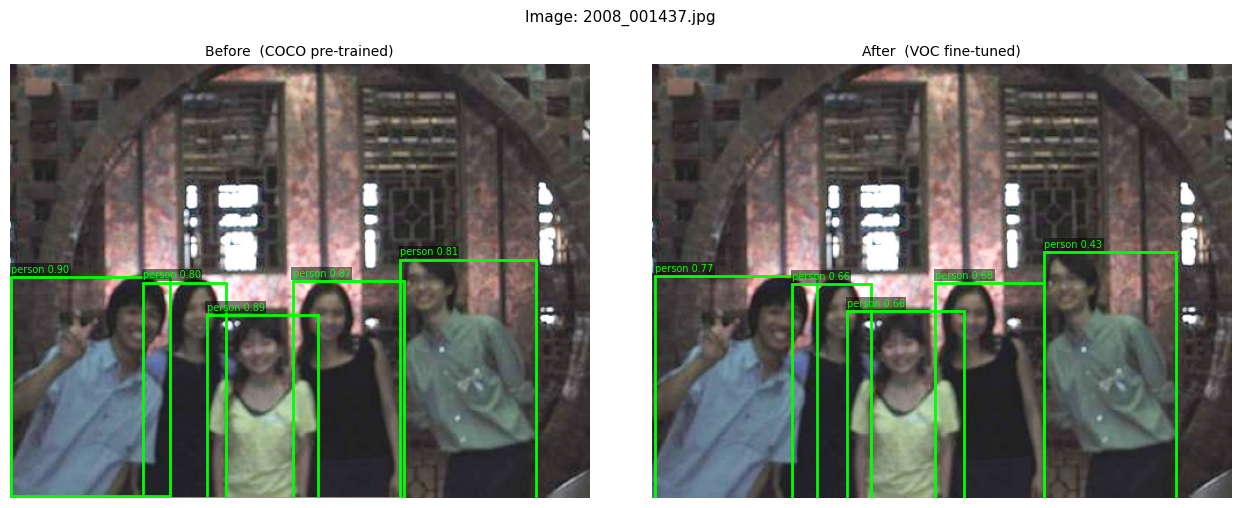

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


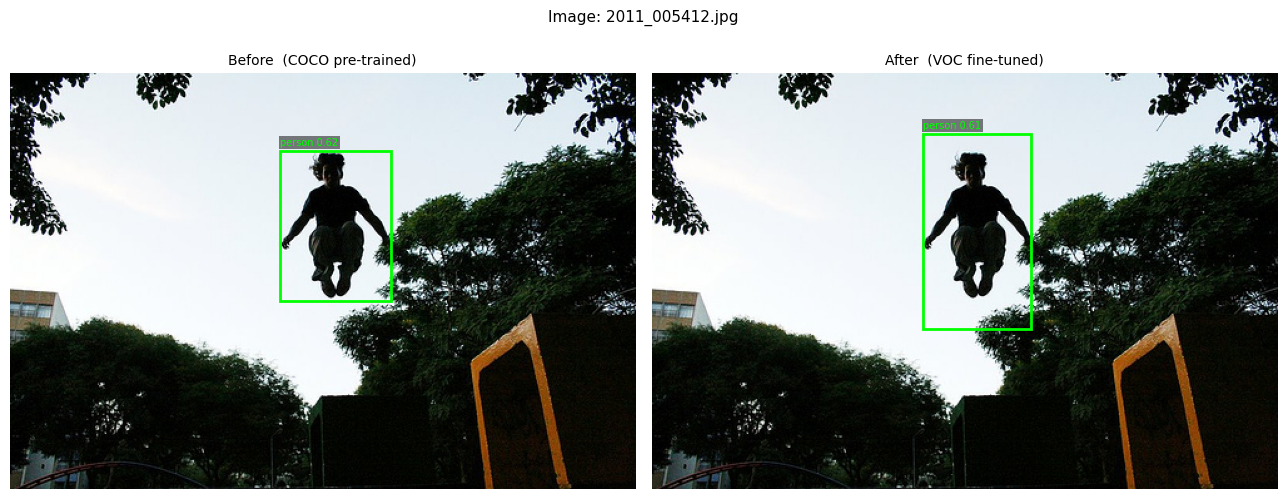

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


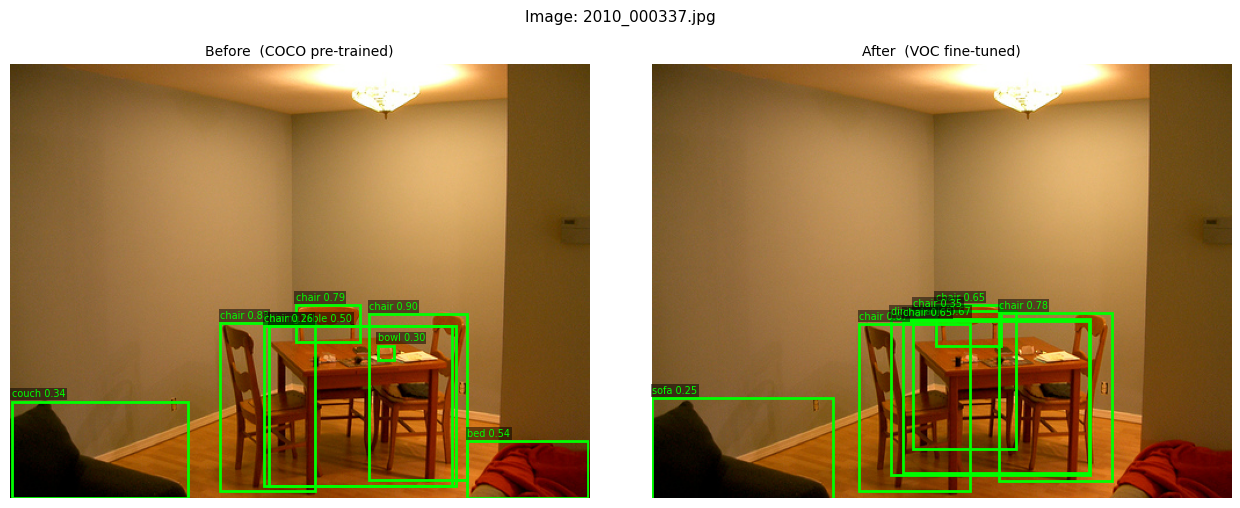

In [15]:
from IPython.display import display as ipy_display

def draw_boxes(ax, img_np, model, img_path, title):
    res   = model(str(img_path))
    preds = res.pandas().xyxy[0]
    ax.imshow(img_np)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    for _, row in preds.iterrows():
        x1, y1, x2, y2 = row['xmin'], row['ymin'], row['xmax'], row['ymax']
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(y1 - 4, 0),
            f"{row['name']} {row['confidence']:.2f}",
            color='lime', fontsize=7,
            bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none')
        )

# load fine-tuned model
model_finetuned = torch.hub.load(
    'ultralytics/yolov5', 'custom',
    path='runs/train/exp1_lr001/weights/best.pt',
    force_reload=True
)
model_finetuned.to(DEVICE)
model_finetuned.eval()

for img_path in val_imgs:
    img_np = np.array(Image.open(img_path).convert('RGB'))
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Image: {img_path.name}', fontsize=11, y=1.01)
    draw_boxes(axes[0], img_np, model_pretrained, img_path, 'Before  (COCO pre-trained)')
    draw_boxes(axes[1], img_np, model_finetuned,  img_path, 'After  (VOC fine-tuned)')
    plt.tight_layout()
    ipy_display(fig)   # forces inline render
    plt.close(fig)     # prevent stacking

## 10. Analysis & Discussion

**What worked:**

I noticed that even the pre-trained model does a decent job because VOC classes (car, person, dog) overlap a lot with COCO. Transfer learning made sense here since the backbone features are generic enough to reuse.

After fine-tuning, the model started detecting VOC-specific categories more confidently. The bounding boxes also looked tighter.

**What didn't go perfectly:**

With only 500 training images and 10 epochs, the mAP is still pretty low. I think more data and more epochs would help a lot. I also noticed that small objects like 'bottle' or 'pottedplant' were often missed — probably because 500 images isn't enough to see those edge cases.

**About the learning rate experiments:**

Honestly, lr=0.01 and lr=0.001 gave similar results at 10 epochs. I noticed the lower lr was slower to start improving but maybe would do better with more epochs. This part was a bit confusing because both loss curves looked almost the same in the first few epochs.

**Overfitting?**

The training loss kept going down while val mAP kind of plateaued around epoch 7-8. That might be a sign of slight overfitting with this small dataset.

## 11. Conclusion

- YOLOv5 is fast and relatively easy to use once the data is in the right format
- Transfer learning really helps — even freezing most of the network and only training the head gave visible improvement
- The dataset size matters a lot — 500 images is too small for 20 classes, but it was good enough to see the idea work
- Lower learning rate didn't obviously help at 10 epochs, would need to test with more epochs to be sure
- Converting VOC XML annotations to YOLO format was the most tedious part of this assignment
- Overall I now understand how pre-trained models can be adapted to new datasets without training from scratch